# Lecture 8 — From the telephone game to the Ising model

In [1]:
# Housekeeping code...
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from IPython.display import display

BLUE = '#3B6FB6'
ORANGE = '#D97706'
GOLD = '#C9A227'
PINK = '#B64E77'
OLIVE = '#718355'
INK = '#263238'
GREY = '#9AA0A6'
LIGHT = '#E7EAED'
SPIN_MAP = ListedColormap([ORANGE, BLUE])

plt.rcParams.update({
    'figure.dpi': 120, 'figure.figsize': (9, 4.6),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 13, 'axes.labelsize': 14, 'legend.fontsize': 11,
    'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, PINK, OLIVE, GOLD]),
})

def telephone(p_flip, relays, trials, seed=567):
    """Independent fair input bits, followed by independent binary copying errors."""
    if not 0 <= p_flip <= 1:
        raise ValueError('p_flip must lie between zero and one.')
    rng = np.random.default_rng(seed)
    first = rng.choice([-1, 1], size=(trials, 1))
    factors = np.where(rng.random((trials, relays)) < p_flip, -1, 1)
    return np.concatenate([first, first * np.cumprod(factors, axis=1)], axis=1)

def binary_entropy(probability):
    p = np.clip(np.asarray(probability, dtype=float), 0, 1)
    result = np.zeros_like(p)
    inside = (p > 0) & (p < 1)
    result[inside] = -(p[inside] * np.log2(p[inside])
                       + (1 - p[inside]) * np.log2(1 - p[inside]))
    return result

def spin_strip(ax, states, *, xlabel='Relay position', ylabel='Independent message'):
    ax.imshow(np.atleast_2d(states), cmap=SPIN_MAP, vmin=-1, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set(xlabel=xlabel, ylabel=ylabel)

def spin_legend(ax, **kwargs):
    return ax.legend(handles=[Patch(color=BLUE, label='+1'), Patch(color=ORANGE, label='−1')],
                     ncol=2, frameon=False, **kwargs)

## Long-range correlations in bird flocks?

<img src="../media/spatial-order/cavagna-2010-velocity-maps.png" alt="Measured starling velocities in panel A and deviations from the flock mean in panel B; the arrow scales differ." width="900">

Cavagna et al. (2010). [*Scale-free correlations in starling flocks*](https://doi.org/10.1073/pnas.1005766107). PNAS **107**, 11865–11870.

We are going to build up to this over two lectures.


## Errors in message transmission

> ### Demo: the telephone game
>
> Line up!

### Let's consider the transmission of one bit of information

Replace a sentence with a binary state:

$$
s_i\in\{-1,+1\}.
$$

Person $i+1$ copies person $i$ correctly with probability $1-p_{\mathrm{flip}}$ and reverses the sign with probability $p_{\mathrm{flip}}$.

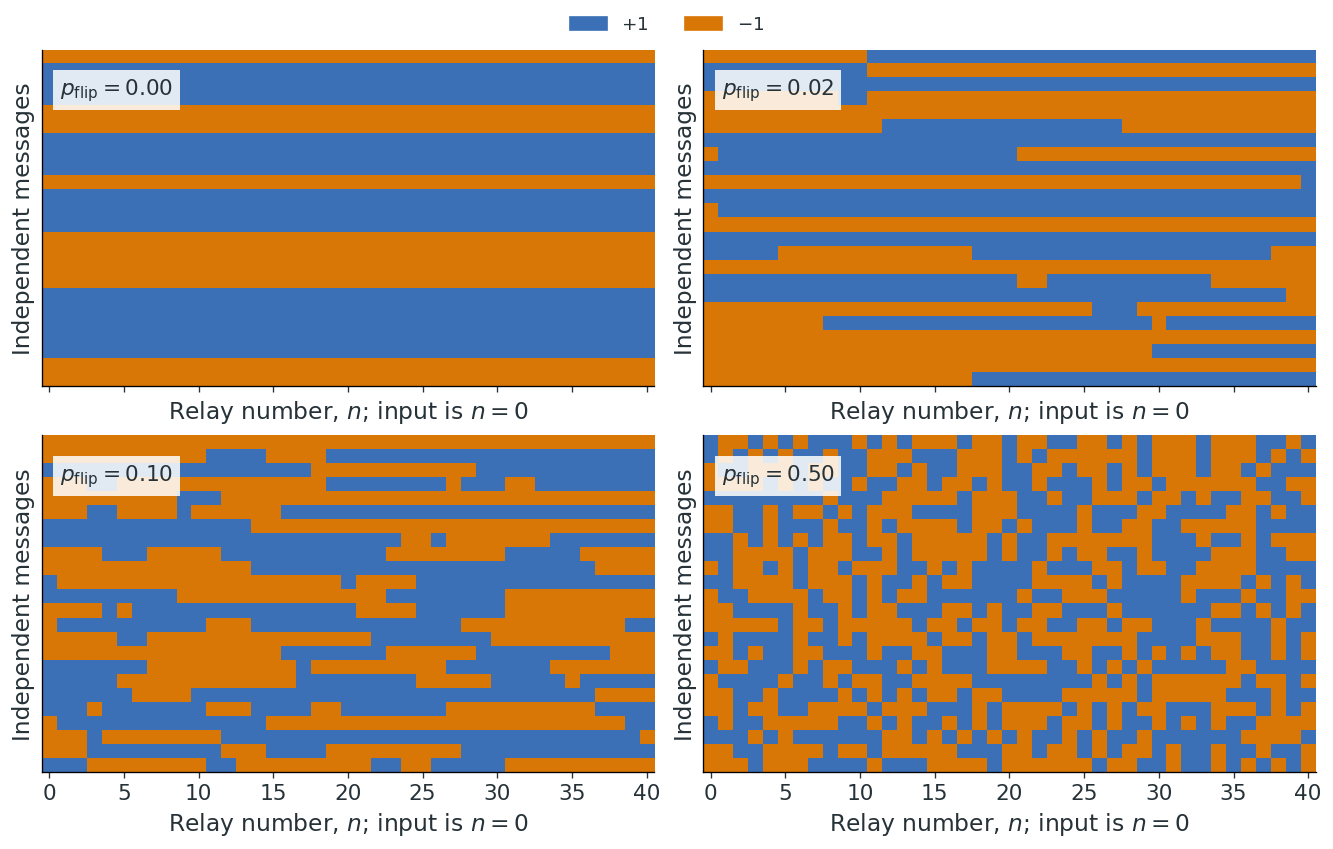

In [2]:
# Projector simulation: each row is a separate binary message.
# This cell runs on its own; it does not depend on the setup cell above.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

BLUE = '#3B6FB6'
ORANGE = '#D97706'
spin_map = ListedColormap([ORANGE, BLUE])

number_of_relays = 40
number_of_messages = 24
error_probabilities = [0.00, 0.02, 0.10, 0.50]
random_seed = 567

rng = np.random.default_rng(random_seed)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True,
                         layout='constrained')
for ax, p_flip in zip(axes.flat, error_probabilities):
    initial = rng.choice([-1, 1], size=(number_of_messages, 1))
    flips = rng.random((number_of_messages, number_of_relays)) < p_flip
    multipliers = np.where(flips, -1, 1)
    messages = np.concatenate(
        [initial, initial * np.cumprod(multipliers, axis=1)], axis=1)
    ax.imshow(messages, cmap=spin_map, vmin=-1, vmax=1,
              aspect='auto', interpolation='nearest')
    ax.set_ylabel('Independent messages')
    ax.set_xlabel('Relay number, $n$; input is $n=0$')
    ax.text(0.03, 0.92, fr'$p_{{\rm flip}}={p_flip:.2f}$',
            transform=ax.transAxes, va='top', ha='left',
            bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':0.85})
    ax.set_yticks([])
fig.legend(handles=[Patch(color=BLUE, label='$+1$'),
                    Patch(color=ORANGE, label='$-1$')],
           loc='outside upper center', ncol=2, frameon=False)
plt.show()

### An error can repair an earlier error

$$
+1\;\longrightarrow\;+1\;\longrightarrow\;-1\;\longrightarrow\;-1\;\longrightarrow\;+1.
$$

The final message agrees with the original after two (or any even number of) flips.

Endpoint agreement depends on the **parity** of the number of errors.

### The product scores agreement

| First state | Later state | Product |
| --- | --- | --- |
| $+1$ | $+1$ | $+1$ |
| $-1$ | $-1$ | $+1$ |
| $+1$ | $-1$ | $-1$ |
| $-1$ | $+1$ | $-1$ |

### Correlation measures agreement above chance

The product is $+1$ when the message matches the input and $-1$ when it differs.

To calculate the correlation, we average this product over many independent messages.

$$
C(n)=\langle s_0s_n\rangle_{\rm messages}.
$$

If you lose all information about the input, $+1$ and $-1$ products occur equally often, so $C(n)=0$.

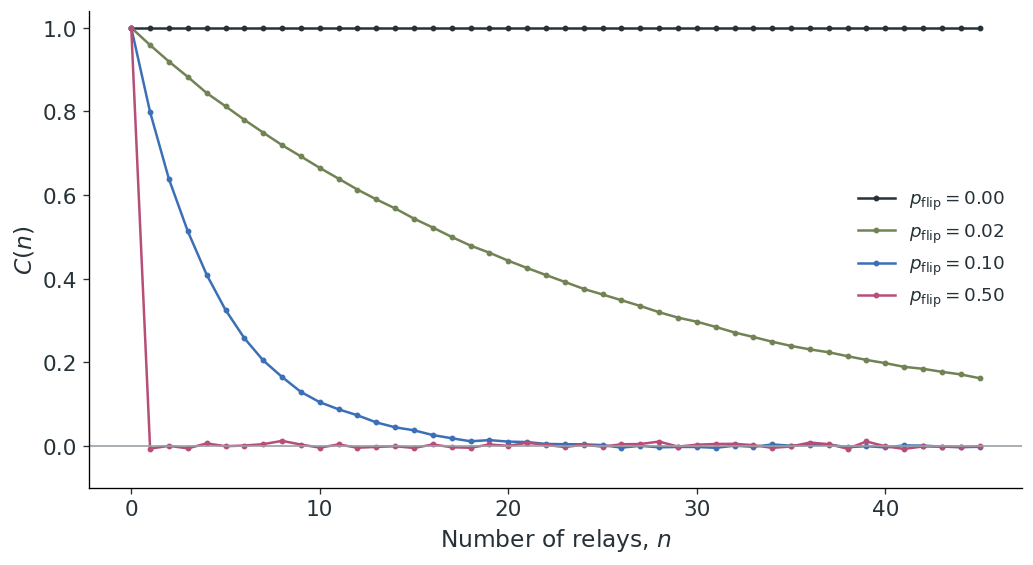

In [3]:
p_flips = [0.00, 0.02, 0.10, 0.50]
colors = [INK, OLIVE, BLUE, PINK]
number_of_relays = 45
number_of_messages = 50000
relays = np.arange(number_of_relays + 1)
fig, ax = plt.subplots(figsize=(8.5, 4.6), layout='constrained')
for p_flip, color in zip(p_flips, colors):
    samples = telephone(p_flip, number_of_relays, number_of_messages,
                        seed=801)
    pair_products = samples[:, :1] * samples
    correlation = pair_products.mean(axis=0)
    ax.plot(relays, correlation, 'o-', ms=2.5, color=color,
            label=fr'$p_{{\mathrm{{flip}}}}={p_flip:.2f}$')
    if p_flip == 0.10:
        measured_C = correlation
        sem_C = pair_products.std(axis=0, ddof=1) / np.sqrt(len(samples))
ax.axhline(0, color=GREY, lw=1)
ax.set(xlabel='Number of relays, $n$', ylabel='$C(n)$', ylim=(-0.1, 1.04))
ax.legend(frameon=False)
plt.show()

At each relay:

$$
s_{n+1}=\begin{cases}
s_n & \text{with probability }1-p_{\mathrm{flip}},\\
-s_n & \text{with probability }p_{\mathrm{flip}}.
\end{cases}
$$

$$
\begin{aligned}
C(n+1)&=(1-p_{\mathrm{flip}})C(n)+p_{\mathrm{flip}}[-C(n)]\\
&=(1-2p_{\mathrm{flip}})C(n).
\end{aligned}
$$

Each step multiplies the correlation by $1-2p_{\mathrm{flip}}$.

For $0<p_{\mathrm{flip}}<1/2$:

$$
\begin{aligned}
C(n)&=(1-2p_{\mathrm{flip}})^n\\
&=\exp[n\ln(1-2p_{\mathrm{flip}})]\\
&=e^{-n/\xi}
\end{aligned}
$$

The correlation function decays exponentially, with a *correlation length* of

$$
\xi=-\frac{1}{\ln(1-2p_{\mathrm{flip}})}
$$

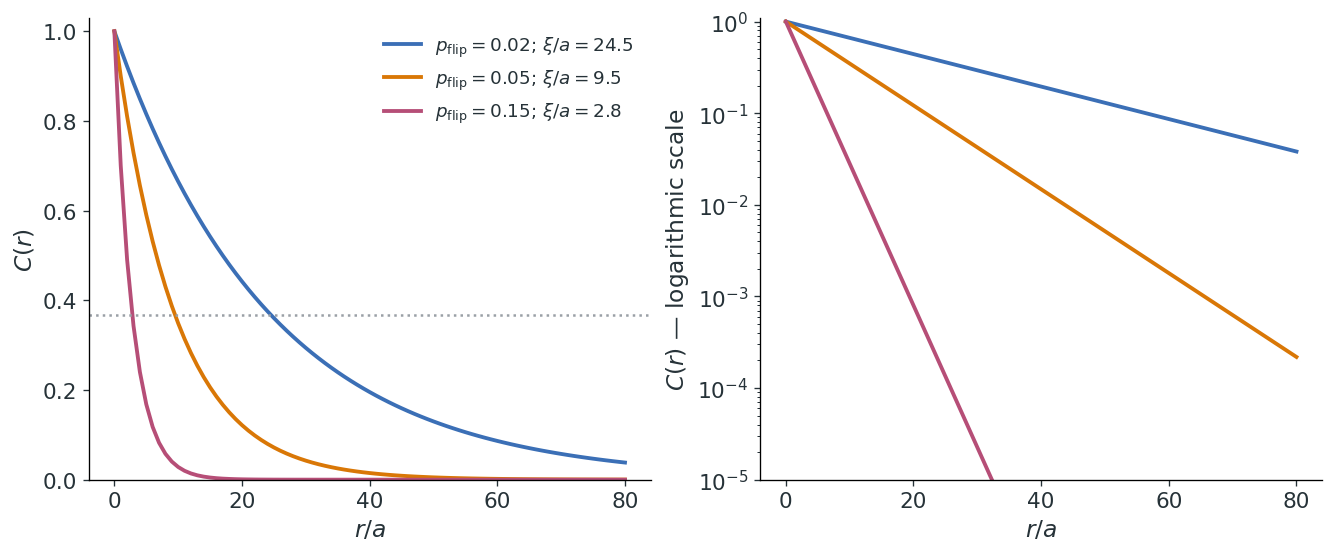

In [4]:
n = np.arange(81)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
for p, color in [(0.02, BLUE), (0.05, ORANGE), (0.15, PINK)]:
    xi = -1 / np.log(1 - 2*p)
    corr = (1 - 2*p)**n
    label = fr'$p_{{\rm flip}}={p:.2f}$; $\xi/a={xi:.1f}$'
    axes[0].plot(n, corr, color=color, lw=2.3, label=label)
    axes[1].semilogy(n, corr, color=color, lw=2.3)
axes[0].axhline(np.exp(-1), color=GREY, ls=':')
axes[0].legend(frameon=False)
axes[0].set(xlabel='$r/a$', ylabel='$C(r)$', ylim=(0, 1.03))
axes[1].set(xlabel='$r/a$', ylabel='$C(r)$ — logarithmic scale', ylim=(1e-5, 1.1))
plt.show()

### Three different lengths

For a chain of $N$ people:

<img src="../media/spatial-order/chain-three-lengths.svg" alt="One-bond interaction range, a correlation length spanning several bonds, and the full chain extent of N minus 1 bonds." width="950">

Correlations can extend over many relays even though each person copies only one other person.

The ratio of the correlation length to the system size, $\xi/(N-1)$, decreases with the system size...

If the error rate is small, $p_{\mathrm{flip}} \ll 1$,

$$
-\ln(1-2p_{\mathrm{flip}})=2p_{\mathrm{flip}}+2p_{\mathrm{flip}}^2+\frac{8}{3}p_{\mathrm{flip}}^3+\cdots.
$$

Therefore

$$
\begin{aligned}
\xi&=\frac{1}{2p_{\mathrm{flip}}+2p_{\mathrm{flip}}^2+\cdots}\\
&=\frac{1}{2p_{\mathrm{flip}}}\frac{1}{1+p_{\mathrm{flip}}+\cdots}\\
&\simeq\frac{1}{2p_{\mathrm{flip}}}.
\end{aligned}
$$

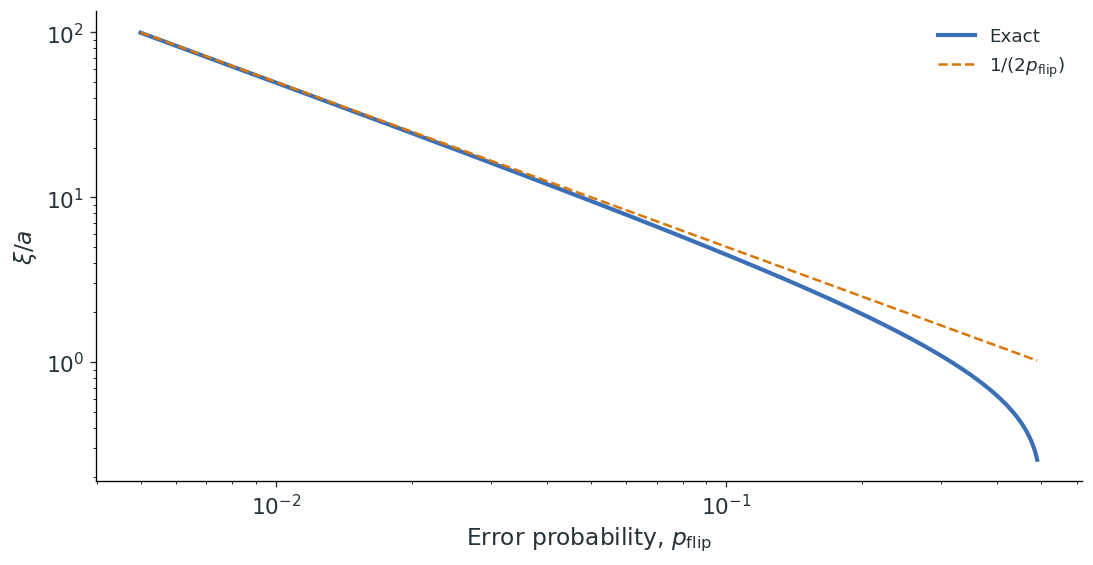

In [5]:
p = np.linspace(0.005, 0.49, 500)
fig, ax = plt.subplots(layout='constrained')
ax.loglog(p, -1/np.log(1 - 2*p), color=BLUE, lw=2.5, label='Exact')
ax.loglog(p, 1/(2*p), color=ORANGE, ls='--', label=r'$1/(2p_{\mathrm{flip}})$')
ax.set(xlabel=r'Error probability, $p_{\mathrm{flip}}$', ylabel=r'$\xi/a$')
ax.legend(frameon=False)
plt.show()

## Mutual information between the input and output

The input is equally likely to be $+1$ or $-1$. Before seeing the output, its uncertainty is 1 bit.

### Binary entropy measures uncertainty

For two possible states with probabilities $q$ and $1-q$, the entropy is

$$
H(q)=-q\log_2q-(1-q)\log_2(1-q).
$$

$H(1/2)=1$ bit; $H(0)=H(1)=0$.

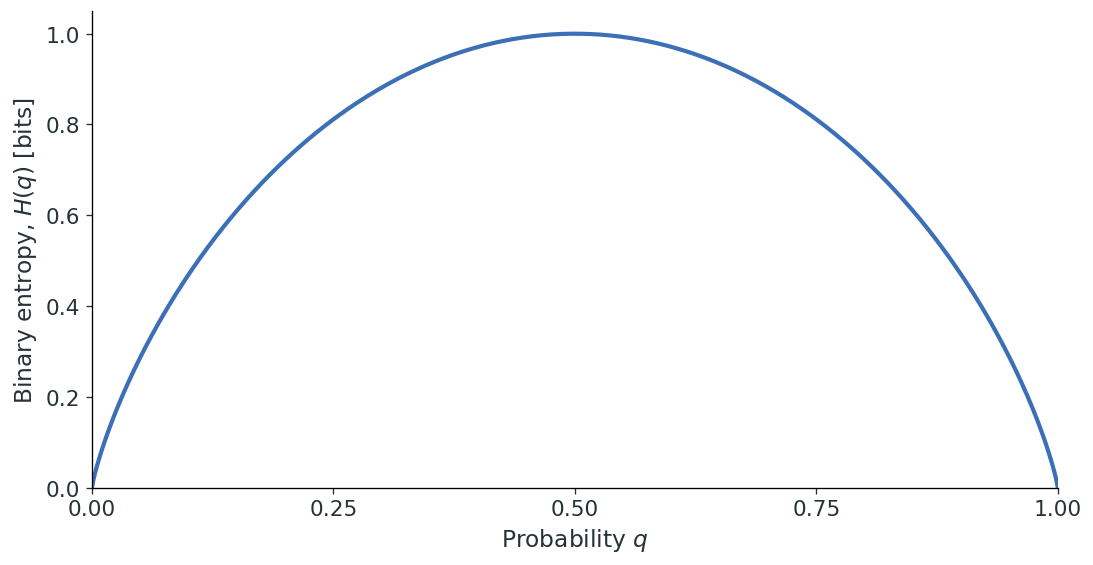

In [6]:
q = np.linspace(0, 1, 501)
fig, ax = plt.subplots(layout='constrained')
ax.plot(q, binary_entropy(q), color=BLUE, lw=2.5)
ax.set(xlabel='Probability $q$', ylabel='Binary entropy, $H(q)$ [bits]',
       xlim=(0, 1), ylim=(0, 1.05))
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
plt.show()

### The endpoint error probability 

The final sign differs from the input with probability

$$
e_n=\frac{1-C(n)}{2}.
$$

After observing the output, the uncertainty about the input is $H(e_n)$ bits.

### Mutual information is the reduction in the uncertainty

$$
I(s_0;s_n)=1-H(e_n)=1-H\!\left(\frac{1-C(n)}{2}\right).
$$

$C=0$ gives $I=0$. If $C=1$ or $C=-1$, the output determines the input and $I=1$ bit.

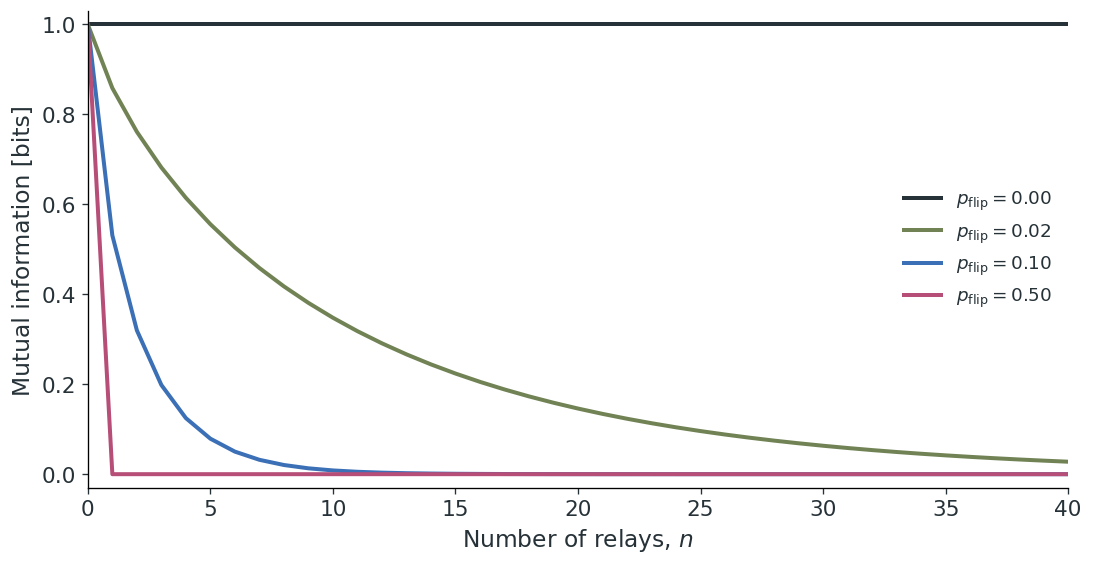

In [7]:
n = np.arange(41)
fig, ax = plt.subplots(layout="constrained")
for p_flip, color in [(0.00, INK), (0.02, OLIVE), (0.10, BLUE), (0.50, PINK)]:
    correlation = (1 - 2*p_flip)**n
    information = 1 - binary_entropy((1 - correlation)/2)
    ax.plot(n, information, color=color, lw=2.4,
            label=fr"$p_{{\mathrm{{flip}}}}={p_flip:.2f}$")
ax.set(xlabel="Number of relays, $n$", ylabel="Mutual information [bits]",
       xlim=(0, 40), ylim=(-0.03, 1.03))
ax.legend(frameon=False)
plt.show()

## The Ising model of magnetization?

A ferromagnet contains atomic magnetic spins that favor alignment with their neighbors, but thermal fluctuations disrupt that alignment.

The **Ising model** is a simplified version of this:

- A magnetic moment at each fixed site can have one of two values, pointing up $\uparrow$ or down $\downarrow$.
- Interactions exist between neighboring spins.
- Temperature controls the probability of different configurations.

### You can use the Ising model for many things

<img src="../media/spatial-order/ising-three-interpretations.svg" alt="The same binary pattern represented as up/down magnetic moments, occupied/empty lattice sites, and species A/B in a binary mixture." width="1000">

| System | Two states | Collective phenomenon |
| --- | --- | --- |
| Magnet | Moment up / down | Spontaneous magnetization |
| Lattice model of a fluid | Site occupied / empty | Liquid–gas coexistence |
| Binary mixture | Species A / B | Mixing or phase separation |


### Spatial order in a lipid membrane

<img src="../media/spatial-order/honerkamp-smith-2008-membrane-sequence.png" alt="Fluorescence microscopy of a model lipid membrane at nine temperatures near its miscibility transition." width="670">

Cooling this model membrane produces regions with different lipid compositions. Near the transition, the size of the composition fluctuations grows.

The measured growth of the correlation length (domain size) agrees with the two-dimensional Ising prediction.

Honerkamp-Smith et al. (2008). [*Line tensions, correlation lengths, and critical exponents in lipid membranes near critical points*](https://doi.org/10.1529/biophysj.107.128421). Biophysical Journal **95**, 236–246.


### The Ising model can also be applied to neuron spiking

**Neuronal recordings:** in a short time bin, a neuron either spikes or doesn't. Ising models fitted to firing rates and pairwise correlations predict the probabilities of collective activity patterns in small retinal populations (Schneidman, Nature 2006).

**Associative memory:** Hopfield networks use interacting binary units to store patterns. Starting from an incomplete or corrupted pattern, the network can recover a stored pattern (Hopfield, PNAS 1982). 

## The 1D Ising model

Consider the one-dimensional Ising model: a chain of $N$ magnetic spins, $\mathbf{s}=(s_1,\ldots,s_N)$, with $s_i=\pm1$.

Neighboring spins favor the same sign. The energy of the chain is

$$
E(\mathbf s)=-J\sum_{i=1}^{N-1}s_i s_{i+1},\qquad J>0.
$$

| Neighbor pair | $s_i s_{i+1}$ | Bond energy |
| --- | --- | --- |
| Equal | $+1$ | $-J$ |
| Opposite | $-1$ | $+J$ |

A bond between opposite spins is a domain wall and costs energy $2J$.

### Higher-energy configurations are less likely

At temperature $T$, the equilibrium probability of a spin configuration is

$$
p(\mathbf s)=\frac{e^{-\beta E(\mathbf s)}}{\mathcal Z},\qquad \beta=\frac{1}{k_BT},\qquad \mathcal Z=\sum_{\mathbf s}e^{-\beta E(\mathbf s)}.
$$

Adding one domain wall raises the energy by $2J$, reducing the configuration probability by a factor $e^{-2\beta J}$.

### Temperature determines the flip probability

For an open chain with no magnetic field, a bond is either aligned (energy $-J$) or opposite (energy $+J$). Therefore

$$
\begin{aligned}
p_{\mathrm{flip}}&=\frac{e^{-\beta J}}{e^{\beta J}+e^{-\beta J}}\\
&=\frac{1}{1+e^{2\beta J}}.
\end{aligned}
$$

### The flip rule reproduces the Ising distribution

For one bond, the Ising probability is the telephone-game copy-or-flip rule:

$$
\frac{e^{\beta J s_i s_{i+1}}}{e^{\beta J}+e^{-\beta J}}=\begin{cases}
1-p_{\mathrm{flip}}, & s_{i+1}=s_i,\\
p_{\mathrm{flip}}, & s_{i+1}=-s_i.
\end{cases}
$$

If we choose the first sign to be $+1$ or $-1$ with equal probability, the probability of a complete chain is

$$
\begin{aligned}
p(s_1,\ldots,s_N)
&=\frac12\prod_{i=1}^{N-1}\frac{e^{\beta J s_i s_{i+1}}}{e^{\beta J}+e^{-\beta J}}\\
&=\frac{e^{-\beta E(\mathbf s)}}{2(e^{\beta J}+e^{-\beta J})^{N-1}}\\
&=\frac{e^{-\beta E(\mathbf s)}}{\mathcal Z}.
\end{aligned}
$$

A chain generated by the telephone game therefore has the same distribution as the open Ising model.

### What is the correlation length?

$$
\begin{aligned}
1-2p_{\mathrm{flip}}
&=1-\frac{2}{1+e^{2\beta J}}\\
&=\frac{e^{2\beta J}-1}{e^{2\beta J}+1}\\
&=\frac{e^{\beta J}-e^{-\beta J}}{e^{\beta J}+e^{-\beta J}}\\
&=\tanh(\beta J).
\end{aligned}
$$

$$
C(n)=[\tanh(\beta J)]^n,
\qquad
\xi=-\frac{1}{\ln[\tanh(\beta J)]}.
$$

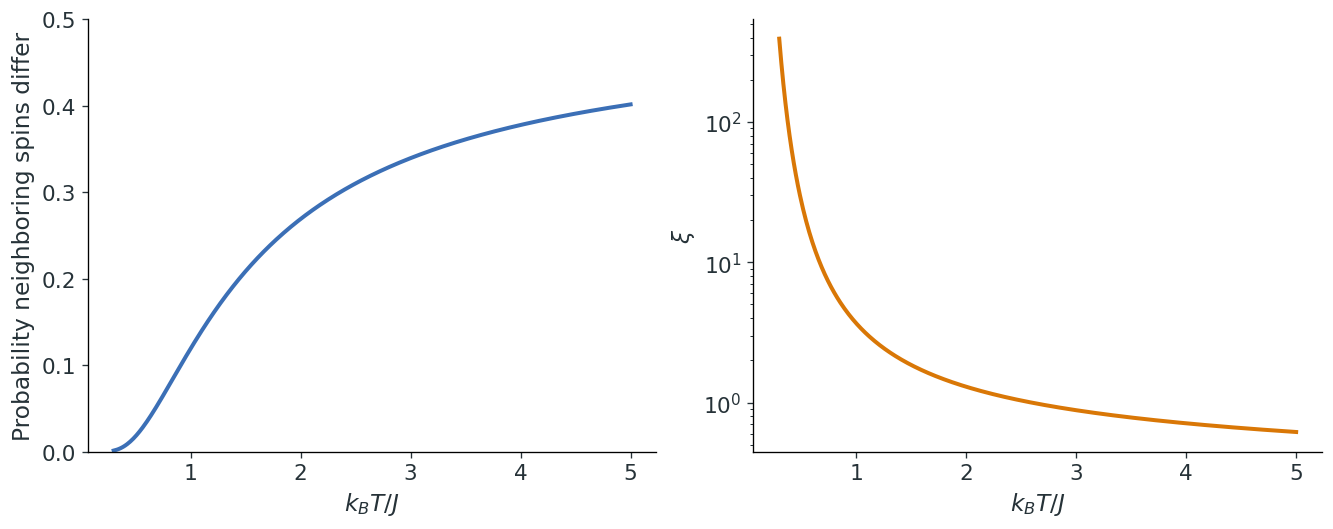

In [8]:
temperature = np.linspace(0.3, 5, 500)  # k_B T / J
q = np.tanh(1/temperature)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), layout='constrained')
axes[0].plot(temperature, 1/(1+np.exp(2/temperature)), color=BLUE, lw=2.4)
axes[0].set(xlabel='$k_B T/J$', ylabel='Probability neighboring spins differ', ylim=(0, 0.5))
axes[1].semilogy(temperature, -1/np.log(q), color=ORANGE, lw=2.4)
axes[1].set(xlabel='$k_B T/J$', ylabel=r'$\xi$')
plt.show()

### Can one extra bond change correlations across the chain?

Join the last spin to the first. Every spin now has two neighbors, and there are two paths between any pair of spins.

If the chain is shorter than $\xi$, the added bond connects spins that are already strongly correlated. If the chain is much longer than $\xi$, its effect should be confined to a small part of the chain.

How does the answer depend on $N/\xi$?

## Closing the Ising chain

The copying rule builds an open chain, one spin at a time. On a ring, $s_N$ also interacts with $s_1$.

To sum over all ring configurations, we need to keep track of the signs at both ends of a partial chain.

### Matrix methods for the Ising model

$$
\mathsf T_{s,s'}=e^{\beta Jss'},\qquad
\mathsf T=\begin{pmatrix}
e^{\beta J}&e^{-\beta J}\\
e^{-\beta J}&e^{\beta J}
\end{pmatrix}.
$$

### Multiplication sums over internal spins in a chain

Fix the first and last spins at $+1$. The middle spin is either $+1$ or $-1$:

$(\uparrow,\uparrow,\uparrow)$ and $(\uparrow,\downarrow,\uparrow)$.

*(I will use $\uparrow$ for $+1$, etc., to distinguish the spins from addition/subtraction...)*

$$
\begin{aligned}
(\mathsf T^2)_{\uparrow,\uparrow}
&=\mathsf T_{\uparrow,\uparrow}\mathsf T_{\uparrow,\uparrow}+\mathsf T_{\uparrow,\downarrow}\mathsf T_{\downarrow,\uparrow}\\
&=e^{\beta J}e^{\beta J}+e^{-\beta J}e^{-\beta J}\\
&=e^{2\beta J}+e^{-2\beta J}.
\end{aligned}
$$

### Sum over the end signs

For three spins, the full matrix is

$$
\mathsf T^2=\begin{pmatrix}
e^{2\beta J}+e^{-2\beta J}&2\\
2&e^{2\beta J}+e^{-2\beta J}
\end{pmatrix}.
$$

The partition function is then:

$$
\mathcal Z=2(e^{2\beta J}+e^{-2\beta J})+4.
$$

For $N$ spins on an open chain, we add the four entries of $\mathsf T^{N-1}$ to find:

$$
\mathcal Z_{\mathrm{open,\ N\ spins}}=2\left(e^{\beta J}+e^{-\beta J}\right)^{N-1}.
$$

### The ring adds a closing bond

For $N$ spins, $\mathsf T^N$ contains $N$ bond factors, including the bond from $s_N$ back to $s_1$. The diagonal entries correspond to the chain starting and ending at the same sign, so the partition function is

$$
\mathcal Z_{\mathrm{ring,\ N\ spins}}=(\mathsf T^N)_{\uparrow,\uparrow}+(\mathsf T^N)_{\downarrow,\downarrow}=\operatorname{Tr}(\mathsf T^N).
$$

### Calculating the partition function for $N$ spins

To evaluate $\operatorname{Tr}(\mathsf T^N)$, use the eigenvalues of the transfer matrix $\mathsf T$:

$$
\mathsf T\mathbf u=\lambda\mathbf u
\quad\Longrightarrow\quad
\mathsf T^2\mathbf u=\lambda^2\mathbf u
\quad\Longrightarrow\quad
\mathsf T^N\mathbf u=\lambda^N\mathbf u.
$$

The two eigenvectors of $\mathsf T$ give:

$$
\begin{aligned}
\mathbf u_+&=\frac1{\sqrt2}\begin{pmatrix}1\\1\end{pmatrix},
&\mathsf T\mathbf u_+&=(e^{\beta J}+e^{-\beta J})\mathbf u_+,\\[6pt]
\mathbf u_-&=\frac1{\sqrt2}\begin{pmatrix}1\\-1\end{pmatrix},
&\mathsf T\mathbf u_-&=(e^{\beta J}-e^{-\beta J})\mathbf u_-.
\end{aligned}
$$

The trace of $\mathsf T^N$ is the sum of its eigenvalues:

$$
\begin{aligned}
\mathcal Z_{\mathrm{ring,\ N\ spins}}
&=\lambda_+^N+\lambda_-^N\\
&=(e^{\beta J}+e^{-\beta J})^N+(e^{\beta J}-e^{-\beta J})^N.
\end{aligned}
$$


### Eigenvalues and the correlation length

The ratio of the two eigenvalues is the same factor that appeared in the telephone-game correlation:

$$
\begin{aligned}
\frac{\lambda_-}{\lambda_+}
&=\frac{e^{\beta J}-e^{-\beta J}}{e^{\beta J}+e^{-\beta J}}\\
&=1-2p_{\mathrm{flip}}.
\end{aligned}
$$

Define $q=\lambda_-/\lambda_+$. For the open chain,

$$
C(n)=q^n,
\qquad
\xi=-\frac{1}{\ln q}.
$$


### Correlations on a ring

Two spins separated by $n$ bonds are also connected by $N-n$ bonds in the other direction.

Summing over the ring configurations gives

$$
C_{\mathrm{ring}}(n)=\frac{q^n+q^{N-n}}{1+q^N}.
$$

The numerator contains a contribution from each direction. The denominator ensures $C_{\mathrm{ring}}(0)=1$.


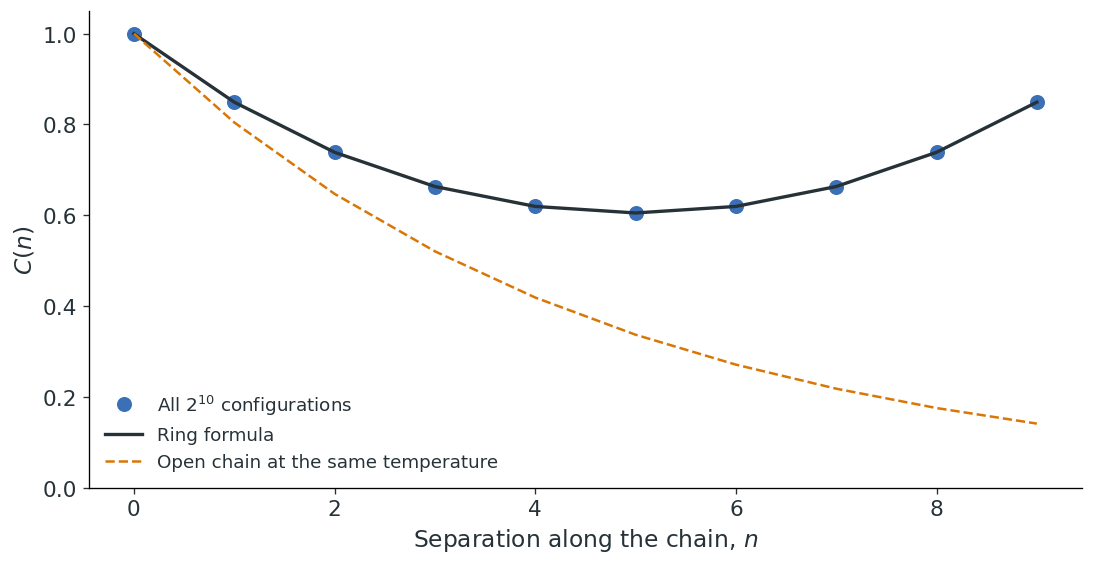

In [9]:
# Enumerate every configuration of a small ring; no Monte Carlo approximation.
N_ring = 10
thermal_ratio = 0.9  # k_B T / J
states = np.array(list(itertools.product([-1, 1], repeat=N_ring)), dtype=np.int8)
energy_over_J = -(states * np.roll(states, -1, axis=1)).sum(axis=1)
log_weights = -energy_over_J / thermal_ratio
weights = np.exp(log_weights - log_weights.max())
probabilities = weights / weights.sum()
exact_enumeration = (probabilities[:, None] * states[:, :1] * states).sum(axis=0)
q = np.tanh(1/thermal_ratio)
n = np.arange(N_ring)
ring_formula = (q**n + q**(N_ring-n)) / (1 + q**N_ring)
assert np.allclose(exact_enumeration, ring_formula, atol=1e-12)

fig, ax = plt.subplots(layout='constrained')
ax.plot(n, exact_enumeration, 'o', ms=8, color=BLUE, label='All $2^{10}$ configurations')
ax.plot(n, ring_formula, '-', color=INK, lw=2, label='Ring formula')
ax.plot(n, q**n, '--', color=ORANGE, label='Open chain at the same temperature')
ax.set(xlabel='Separation along the chain, $n$', ylabel='$C(n)$', ylim=(0, 1.05))
ax.legend(frameon=False)
plt.show()

### A large ring looks locally like an open chain

Since $q^n=e^{-n/\xi}$,

$$
C_{\mathrm{ring}}(n)=\frac{e^{-n/\xi}+e^{-(N-n)/\xi}}{1+e^{-N/\xi}}.
$$

If the longer route has many more bonds than the correlation length, $N-n\gg\xi$, its contribution is negligible:

$$
C_{\mathrm{ring}}(n)\simeq e^{-n/\xi}=C_{\mathrm{open}}(n).
$$

The spin at the origin has little correlation with spins many correlation lengths away. Closing the chain far away has little effect on correlations between nearby spins!


## No finite-temperature ordered phase in 1D

### Any finite temperature produces a finite density of walls

$$
p_{\mathrm{wall}}=\frac1{1+e^{2\beta J}}>0
$$

In an open chain,

$$
\langle N_{\mathrm{wall}}\rangle=(N-1)p_{\mathrm{wall}}.
$$

The expected number of walls grows with the system size!

### How large is the correlation length at low temperature?

For $k_BT\ll J$, flips are rare:

$$
p_{\mathrm{flip}}=\frac{1}{1+e^{2\beta J}}\simeq e^{-2\beta J}\ll1.
$$

Using $\ln(1-2p_{\mathrm{flip}})\simeq-2p_{\mathrm{flip}}$,

$$
\xi=-\frac{1}{\ln(1-2p_{\mathrm{flip}})}
\simeq\frac{1}{2p_{\mathrm{flip}}}
\simeq\frac12 e^{2J/(k_BT)}.
$$

$\xi$ can be much larger than the chain, but is finite at every $T>0$.


### How aligned is the whole chain?

Define the magnetization per spin:

$$
m=\frac1N\sum_{i=1}^N s_i.
$$

With all spins up, $m=1$; with all spins down, $m=-1$. Equal numbers of up and down spins give $m=0$.

Opposite configurations are equally likely, so $\langle m\rangle=0$ even if each chain is fully aligned. 

We can quantify alignment using the mean-square magnetization, $\langle m^2\rangle$.

For an open chain,

$$
\begin{aligned}
\langle m^2\rangle
&=\frac1{N^2}\sum_{i=1}^N\sum_{j=1}^N\langle s_i s_j\rangle\\
&=\frac1{N^2}\left[N+2\sum_{n=1}^{N-1}(N-n)q^n\right].
\end{aligned}
$$


### Alignment vanishes when the chain is much longer than $\xi$

For $N\gg\xi$, correlations become negligible before $n$ reaches $N$.

In the sum, we use the approximation $N-n\simeq N$ and extend the upper limit to infinity:

$$
\begin{aligned}
\langle m^2\rangle
&\simeq\frac1N\left[1+2\sum_{n=1}^{\infty}q^n\right]\\
&=\frac1N\frac{1+q}{1-q}.
\end{aligned}
$$

At every fixed $T>0$, $q<1$, so $\langle m^2\rangle\to0$ as $N\to\infty$. 
*There is no long-range order.*


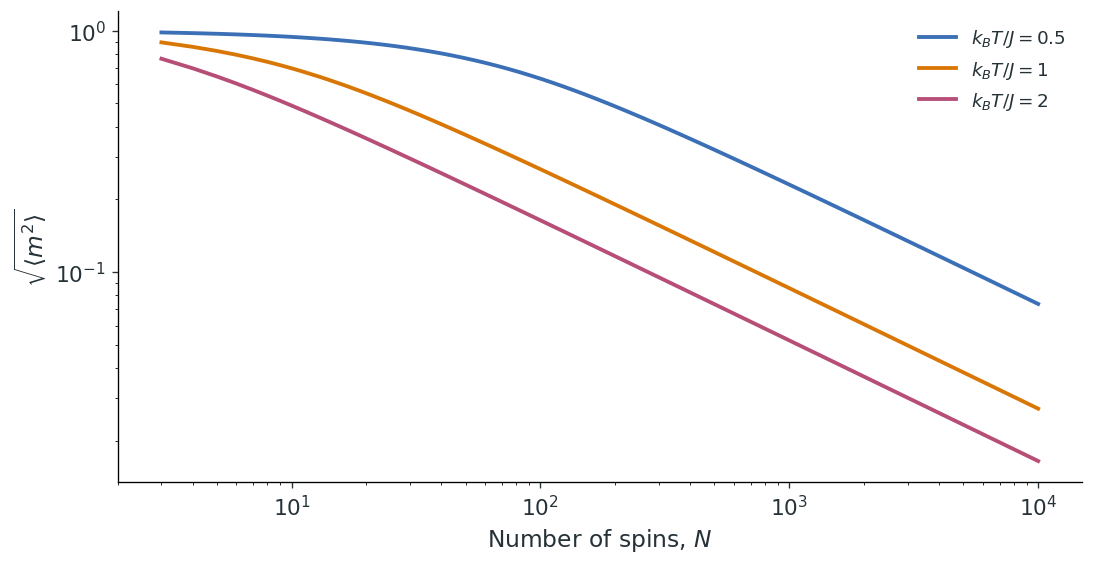

In [10]:
sizes = np.unique(np.logspace(0.5, 4, 80).astype(int))
fig, ax = plt.subplots(layout='constrained')
for temp, color in [(0.5, BLUE), (1.0, ORANGE), (2.0, PINK)]:
    q = np.tanh(1/temp)
    variance = []
    for N in sizes:
        distance = np.arange(1, N)
        variance.append((N + 2*np.sum((N-distance)*q**distance))/N**2)
    ax.loglog(sizes, np.sqrt(variance), color=color, lw=2.3,
              label=fr'$k_BT/J={temp:g}$')
ax.set(xlabel='Number of spins, $N$', ylabel=r'$\sqrt{\langle m^2\rangle}$')
ax.legend(frameon=False)
plt.show()

### Scaling with system size?

Seeing an aligned chain (or flock) doesn't tell you if you have a truly ordered phase.

For the Ising chain at fixed temperature $T>0$, as $N$ increases:

$$
\xi\text{ stays fixed},\qquad \frac{\xi}{N-1}\longrightarrow0.
$$

A small sample can look aligned by chance simply because it is shorter than the correlation length.


### Larger starling flocks have a larger correlated range

<img src="../media/spatial-order/cavagna-2010-figure-2.png" alt="Published starling orientation and speed correlations, with their measured correlation ranges plotted against flock size." width="780">

## Sources

- C. E. Shannon (1948). *A mathematical theory of communication*. Bell System Technical Journal **27**, 379–423, 623–656. [Paper](https://www.cs.yale.edu/homes/yry/readings/general/shannon1948.pdf).
- D. Tong. *Statistical Physics*, section 5.3: the Ising chain and domain walls. [Lecture notes](https://www.damtp.cam.ac.uk/user/tong/statphys/statmechhtml/S5.html).
- E. Ising (1925). *Beitrag zur Theorie des Ferromagnetismus*. Zeitschrift für Physik **31**, 253–258. [Article](https://doi.org/10.1007/BF02980577).
- A. Cavagna et al. (2010). *Scale-free correlations in starling flocks*. PNAS **107**, 11865–11870. [Article](https://doi.org/10.1073/pnas.1005766107).